# **LAB Slot 13 – Time Series Analysis: Air Passengers**

**Dataset:** [Air Passengers – Kaggle](https://www.kaggle.com/datasets/rakannimer/air-passengers)

**Nội dung bài lab:**
1. Đọc dữ liệu & chuẩn bị
2. Vẽ biểu đồ đường (Line Plot)
3. Nhận xét bằng mắt thường (Trend & Seasonality)
4. Phân rã chuỗi thời gian (Seasonal Decompose)
5. Tìm phương trình mô tả dữ liệu
6. Dự đoán & tính RMSE (Train/Test Split)

In [1]:
# ── Install required libraries (chạy lần đầu nếu thiếu) ──────────────────────
import subprocess, sys

required = ["pandas", "matplotlib", "statsmodels", "scikit-learn", "numpy"]
for pkg in required:
    subprocess.run([sys.executable, "-m", "pip", "install", pkg, "-q"], check=False)

print("All packages ready.")


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: pip3.10 install --upgrade pip

[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: pip3.10 install --upgrade pip

[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: pip3.10 install --upgrade pip

[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: pip3.10 install --upgrade pip


All packages ready.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: pip3.10 install --upgrade pip


## **1. Đọc dữ liệu & Chuẩn bị**

Đọc file CSV, chuyển cột `Month` sang `datetime` và đặt làm index.

In [8]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_squared_error
import warnings
warnings.filterwarnings("ignore")

CSV_PATH = os.path.join(os.path.dirname(os.path.abspath("lab_13.ipynb")), "AirPassengers.csv")

df = pd.read_csv(CSV_PATH, index_col=0, parse_dates=True)
df.columns = ["Passengers"]
df.index.name = "Month"

df.head()

,Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


## **2. Vẽ biểu đồ đường (Line Plot)**

Biểu đồ thể hiện số lượng hành khách theo từng tháng từ 1949 đến 1960.

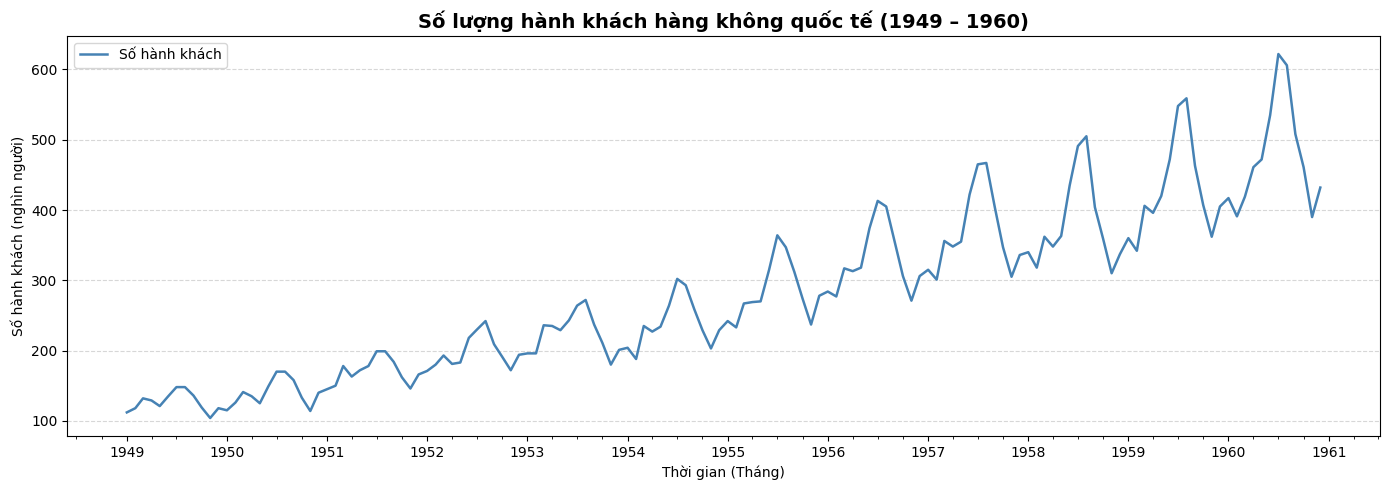

In [9]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df.index, df["Passengers"], color="steelblue", linewidth=1.8, label="Số hành khách")
ax.set_title("Số lượng hành khách hàng không quốc tế (1949 – 1960)", fontsize=14, fontweight="bold")
ax.set_xlabel("Thời gian (Tháng)")
ax.set_ylabel("Số hành khách (nghìn người)")
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_minor_locator(mdates.MonthLocator(bymonth=[4, 7, 10]))
ax.grid(axis="y", linestyle="--", alpha=0.5)
ax.legend()
plt.tight_layout()
plt.show()

## **3. Nhận xét bằng mắt thường**

- **Xu hướng (Trend):**  
Chuỗi thể hiện xu hướng tăng rõ rệt và liên tục từ khoảng 100 nghìn hành khách (năm 1949) lên xấp xỉ 600 nghìn (năm 1960). Xu hướng này gần tuyến tính, tuy nhiên có thể có dạng hàm mũ nhẹ ở những năm cuối.

- **Tính mùa vụ (Seasonality):**  
Chu kỳ mùa vụ 12 tháng xuất hiện đều đặn mỗi năm. Số hành khách đạt đỉnh vào các tháng hè (tháng 6–8) và giảm xuống đáy vào cuối đông (tháng 11–1), phản ánh hành vi du lịch theo mùa.

- **Biên độ mùa vụ:**  
Biên độ dao động giữa đỉnh và đáy trong năm tăng dần theo thời gian, tức là mùa vụ không cố định mà tỉ lệ với mức độ xu hướng. Điều này cho thấy mô hình **nhân (multiplicative)** phù hợp hơn mô hình cộng (additive).

- **Tính dừng (Stationarity):**  
Chuỗi không dừng do cả giá trị trung bình lẫn phương sai đều thay đổi theo thời gian.

## **4. Phân rã chuỗi thời gian (Seasonal Decompose)**

Dùng `seasonal_decompose` với `model='multiplicative'` vì biên độ mùa vụ tăng theo thời gian.

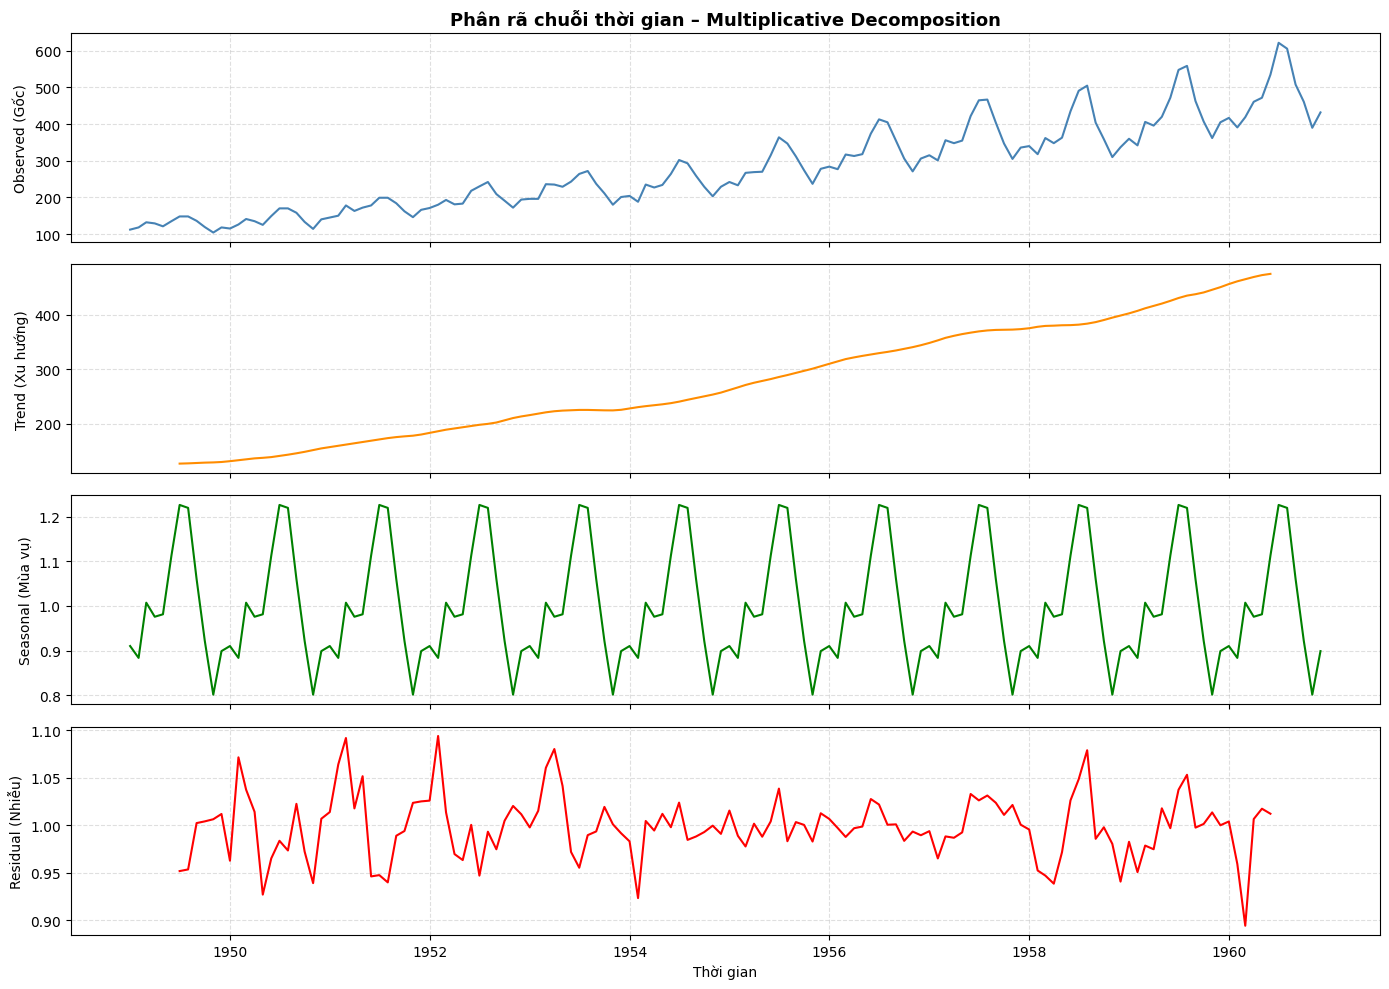


── Seasonal Indices (12 tháng trong năm) ──
Tháng 1     0.910230
Tháng 2     0.883625
Tháng 3     1.007366
Tháng 4     0.975906
Tháng 5     0.981378
Tháng 6     1.112776
Tháng 7     1.226556
Tháng 8     1.219911
Tháng 9     1.060492
Tháng 10    0.921757
Tháng 11    0.801178
Tháng 12    0.898824


In [5]:
decomposition = seasonal_decompose(df["Passengers"], model="multiplicative", period=12)

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)

components = {
    "Observed (Gốc)":   (decomposition.observed,   "steelblue"),
    "Trend (Xu hướng)": (decomposition.trend,      "darkorange"),
    "Seasonal (Mùa vụ)":(decomposition.seasonal,   "green"),
    "Residual (Nhiễu)": (decomposition.resid,       "red"),
}

for ax, (title, (series, color)) in zip(axes, components.items()):
    ax.plot(df.index, series, color=color, linewidth=1.5)
    ax.set_ylabel(title, fontsize=10)
    ax.grid(linestyle="--", alpha=0.4)

axes[0].set_title("Phân rã chuỗi thời gian – Multiplicative Decomposition",
                  fontsize=13, fontweight="bold")
axes[-1].set_xlabel("Thời gian")
plt.tight_layout()
plt.show()

print("\n── Seasonal Indices (12 tháng trong năm) ──")
seasonal_idx = decomposition.seasonal[:12].copy()
seasonal_idx.index = [f"Tháng {i+1}" for i in range(12)]
print(seasonal_idx.to_string())

### Đánh giá Seasonal Indices (12 tháng trong năm)

Seasonal Index phản ánh mức độ lệch của từng tháng so với giá trị trung bình của chuỗi. Trong mô hình nhân (multiplicative), chỉ số bằng 1.0 có nghĩa là tháng đó không bị ảnh hưởng bởi mùa vụ; lớn hơn 1.0 là tháng cao điểm, nhỏ hơn 1.0 là tháng thấp điểm.

| Nhóm tháng | Tháng | Seasonal Index | Nhận xét |
|---|---|---|---|
| Thấp điểm | Tháng 11 | ~0.80 | Tháng thấp nhất trong năm — giai đoạn sau mùa thu, nhu cầu đi lại giảm mạnh |
| Thấp điểm | Tháng 2 | ~0.88 | Tháng thấp thứ hai — đầu năm sau kỳ nghỉ, lưu lượng chưa phục hồi |
| Thấp điểm | Tháng 1, 12 | ~0.91 | Thấp hơn trung bình mặc dù là mùa nghỉ lễ, do dữ liệu gộp cả đi lẫn về |
| Cân bằng | Tháng 3–5, 10 | ~0.97–1.01 | Gần mức trung bình — không có biến động mùa vụ rõ rệt |
| Cao điểm | Tháng 6 | ~1.11 | Bắt đầu mùa hè, nhu cầu du lịch tăng nhanh |
| Cao điểm | Tháng 7 | ~1.23 | Đỉnh cao nhất trong năm — giữa mùa hè, lưu lượng hành khách lớn nhất |
| Cao điểm | Tháng 8 | ~1.22 | Gần bằng tháng 7, vẫn là tháng rất cao điểm |

**Nhận xét chung:** Chuỗi có mùa vụ rõ rệt với biên độ khoảng 0.80 đến 1.23, tức là tháng cao điểm (tháng 7) có lưu lượng cao hơn tháng thấp điểm (tháng 11) khoảng **54%** so với giá trị xu hướng tại cùng thời điểm. Đây là minh chứng rõ ràng cho việc lựa chọn mô hình multiplicative thay vì additive.

## **5. Tìm phương trình mô tả dữ liệu**

Ta nhận thấy:
- **Trend** tăng gần tuyến tính → dùng hồi quy tuyến tính để mô tả xu hướng.
- **Mùa vụ** có chu kỳ 12 tháng → biểu diễn bằng tổ hợp **sin/cos** (Fourier).

**Mô hình tổng quát (Multiplicative):**

$$y_t = (a \cdot t + b) \times S_t \times \varepsilon_t$$

Trong đó:
- $t$: chỉ số tháng (0, 1, 2, …)  
- $\hat{T}_t = a \cdot t + b$ là thành phần trend tuyến tính  
- $S_t = \sum_{k=1}^{K}[\alpha_k \sin(2\pi k t / 12) + \beta_k \cos(2\pi k t / 12)]$ là thành phần Fourier  
- $\varepsilon_t$ là nhiễu

Phương trình Trend tuyến tính:
  T(t) = 2.6669 × t + 103.3168
  (t = 0 tương ứng tháng 1950-01 sau khi bỏ NaN biên)

Phương trình đầy đủ (Trend + Fourier Seasonality):
  ŷ(t) = 89.8444 + 2.6637·t + 5.4778·sin(2π·1t/12) - 45.4857·cos(2π·1t/12) + 16.2328·sin(2π·2t/12) + 19.4276·cos(2π·2t/12)

  R²  = 0.9495
  RMSE (fit) = 26.87 hành khách


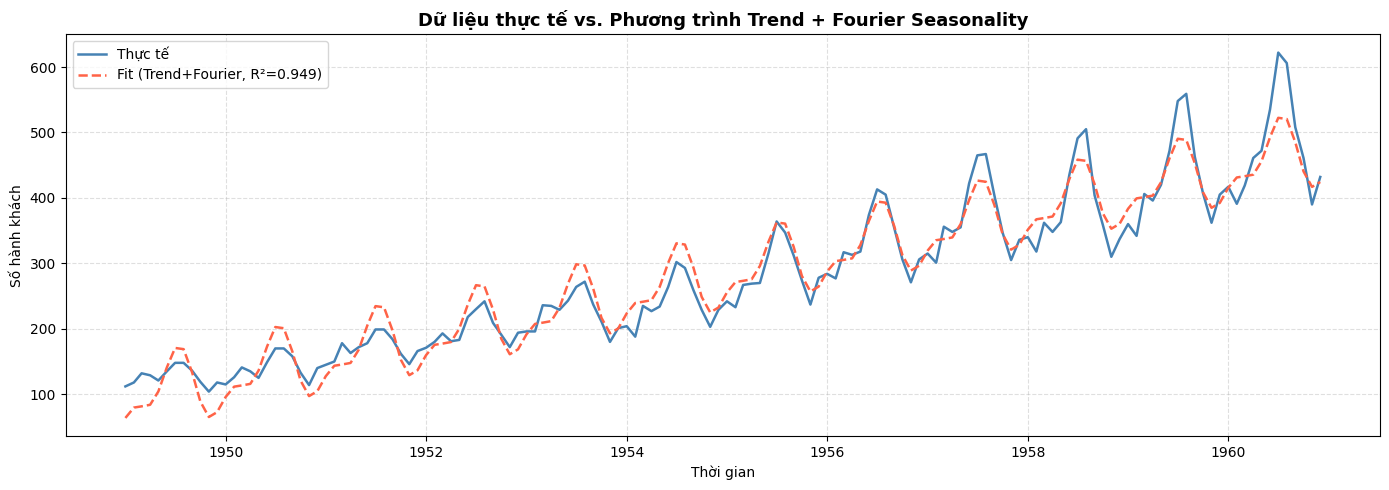

In [6]:
from sklearn.linear_model import LinearRegression
from numpy.polynomial import polynomial as P

n = len(df)
t = np.arange(n)
y = df["Passengers"].values

# ── 5a. Hồi quy tuyến tính lên trend ──────────────────────────────────────────
trend_series = decomposition.trend.dropna().values
t_trend = np.arange(len(trend_series))

lr = LinearRegression()
lr.fit(t_trend.reshape(-1, 1), trend_series)
a, b = lr.coef_[0], lr.intercept_

print(f"Phương trình Trend tuyến tính:\n  T(t) = {a:.4f} × t + {b:.4f}")
print(f"  (t = 0 tương ứng tháng 1950-01 sau khi bỏ NaN biên)")

# ── 5b. Fourier features (K=2 hài) để mô tả mùa vụ ───────────────────────────
K = 2
fourier_cols = []
for k in range(1, K + 1):
    fourier_cols.append(np.sin(2 * np.pi * k * t / 12))
    fourier_cols.append(np.cos(2 * np.pi * k * t / 12))
X_fourier = np.column_stack([t] + fourier_cols)

lr_full = LinearRegression()
lr_full.fit(X_fourier, y)
y_fitted = lr_full.predict(X_fourier)

rmse_fit = np.sqrt(mean_squared_error(y, y_fitted))
r2_fit   = lr_full.score(X_fourier, y)

coef_names = ["t"] + [f"sin(2π·{k}t/12)" if i%2==0 else f"cos(2π·{k}t/12)"
                      for k in range(1, K+1) for i in range(2)]
print("\nPhương trình đầy đủ (Trend + Fourier Seasonality):")
print(f"  ŷ(t) = {lr_full.intercept_:.4f}", end="")
for name, coef in zip(coef_names, lr_full.coef_):
    sign = "+" if coef >= 0 else "-"
    print(f" {sign} {abs(coef):.4f}·{name}", end="")
print()
print(f"\n  R²  = {r2_fit:.4f}")
print(f"  RMSE (fit) = {rmse_fit:.2f} hành khách")

# ── Vẽ kết quả fit ────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df.index, y, label="Thực tế", color="steelblue", linewidth=1.8)
ax.plot(df.index, y_fitted, label=f"Fit (Trend+Fourier, R²={r2_fit:.3f})",
        color="tomato", linewidth=1.8, linestyle="--")
ax.set_title("Dữ liệu thực tế vs. Phương trình Trend + Fourier Seasonality",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Thời gian"); ax.set_ylabel("Số hành khách")
ax.legend(); ax.grid(linestyle="--", alpha=0.4)
plt.tight_layout(); plt.show()

### Đánh giá chỉ số mô hình Trend + Fourier Regression

| Chỉ số | Giá trị | Ý nghĩa |
|---|---|---|
| **R²** | ~0.9495 | Mô hình giải thích được khoảng 95% phương sai của dữ liệu — mức độ khớp rất tốt |
| **RMSE (fit)** | ~26.87 hành khách | Sai số trung bình bình phương gốc trên toàn tập dữ liệu huấn luyện |

**Nhận xét về các hệ số phương trình:**

- **Hệ số của `t` (~2.66):** Mỗi tháng, xu hướng tăng trung bình khoảng 2.66 nghìn hành khách — phản ánh tăng trưởng tuyến tính ổn định.
- **Hệ số `cos(2πt/12)` (~-45.49):** Thành phần hài bậc 1 với biên độ lớn nhất, đóng góp chính vào việc mô tả đỉnh mùa hè và đáy mùa đông.
- **Hệ số `sin(2πt/12)` (~5.48) và các hài bậc 2:** Các thành phần bổ sung giúp mô hình bắt được sự bất đối xứng trong chu kỳ mùa vụ (đỉnh tháng 7–8 nhọn hơn đáy tháng 11–12).

**Hạn chế của mô hình:**  
Mô hình Trend + Fourier là mô hình tuyến tính (additive), trong khi dữ liệu có biên độ mùa vụ tăng dần theo thời gian (multiplicative). Do đó, mô hình sẽ ước lượng thấp ở những năm cuối và ước lượng cao ở những năm đầu. Đây là lý do RMSE trên tập test (~38) cao hơn so với Holt-Winters (~26).

## **6. Chia Train / Test & Dự đoán — Tính RMSE**

Chia **80% train / 20% test** (≈ 115 tháng train, 29 tháng test).  
Dùng **Holt-Winters Exponential Smoothing** (trend + multiplicative seasonality) để dự đoán.

Train: 1949-01 → 1958-07  (115 tháng)
Test : 1958-08  → 1960-12  (29 tháng)

─────────────────── So sánh các mô hình ───────────────────
Mô hình                                 RMSE       MAE      MAPE
Holt-Winters (Exp. Smoothing)          26.04     21.96     4.82%
Trend + Fourier Regression             38.03     28.83     6.31%


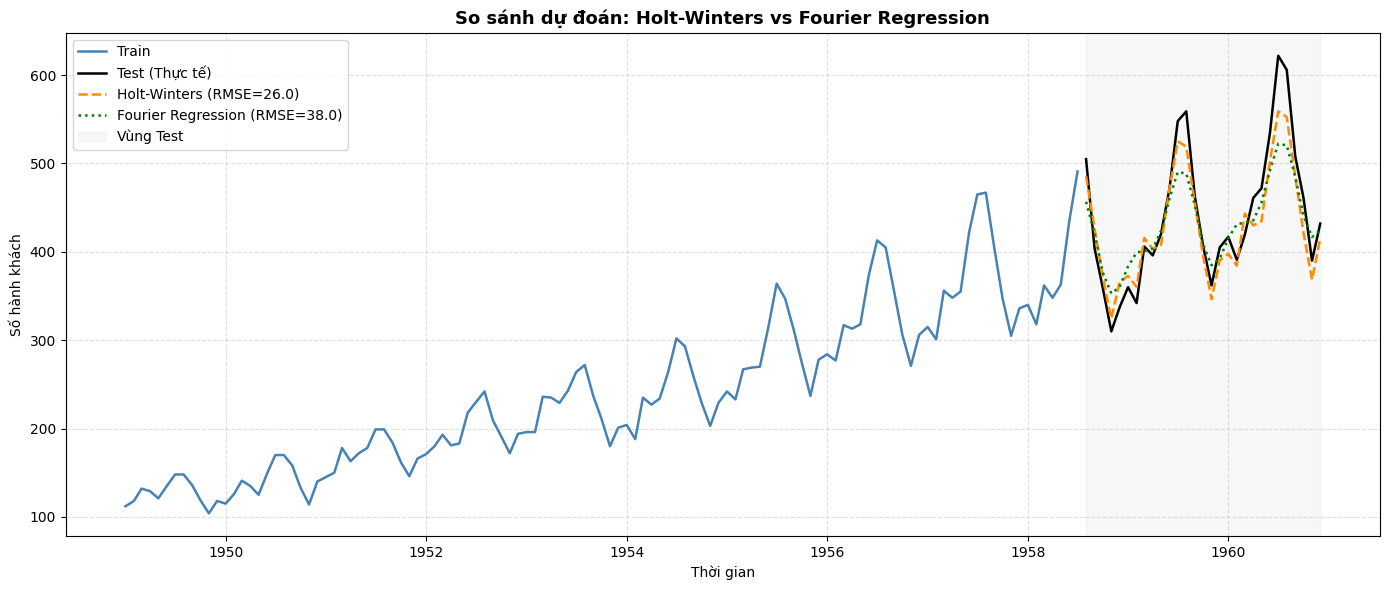

In [7]:
# ── Chia Train / Test ─────────────────────────────────────────────────────────
split_ratio = 0.80
split_idx   = int(len(df) * split_ratio)

train = df.iloc[:split_idx]["Passengers"]
test  = df.iloc[split_idx:]["Passengers"]

print(f"Train: {train.index[0].strftime('%Y-%m')} → {train.index[-1].strftime('%Y-%m')}  ({len(train)} tháng)")
print(f"Test : {test.index[0].strftime('%Y-%m')}  → {test.index[-1].strftime('%Y-%m')}  ({len(test)} tháng)")

# ── Mô hình 1: Holt-Winters (Triple Exponential Smoothing) ───────────────────
hw_model = ExponentialSmoothing(
    train,
    trend="add",
    seasonal="mul",
    seasonal_periods=12,
    initialization_method="estimated",
)
hw_fit    = hw_model.fit(optimized=True)
hw_pred   = hw_fit.forecast(len(test))

rmse_hw  = np.sqrt(mean_squared_error(test, hw_pred))
mae_hw   = np.mean(np.abs(test.values - hw_pred.values))
mape_hw  = np.mean(np.abs((test.values - hw_pred.values) / test.values)) * 100

# ── Mô hình 2: Fourier + Trend (từ Bước 5) ───────────────────────────────────
t_test   = np.arange(split_idx, n)
X_test_f = np.column_stack(
    [t_test] + [np.sin(2*np.pi*k*t_test/12) if i%2==0
                 else np.cos(2*np.pi*k*t_test/12)
                 for k in range(1, K+1) for i in range(2)]
)
fourier_pred = lr_full.predict(X_test_f)

rmse_fourier = np.sqrt(mean_squared_error(test, fourier_pred))
mae_fourier  = np.mean(np.abs(test.values - fourier_pred))
mape_fourier = np.mean(np.abs((test.values - fourier_pred) / test.values)) * 100

# ── Kết quả ───────────────────────────────────────────────────────────────────
print("\n─────────────────── So sánh các mô hình ───────────────────")
print(f"{'Mô hình':<35} {'RMSE':>8}  {'MAE':>8}  {'MAPE':>8}")
print(f"{'Holt-Winters (Exp. Smoothing)':<35} {rmse_hw:>8.2f}  {mae_hw:>8.2f}  {mape_hw:>7.2f}%")
print(f"{'Trend + Fourier Regression':<35} {rmse_fourier:>8.2f}  {mae_fourier:>8.2f}  {mape_fourier:>7.2f}%")

# ── Biểu đồ so sánh ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(train.index, train, label="Train", color="steelblue", linewidth=1.8)
ax.plot(test.index,  test,  label="Test (Thực tế)", color="black", linewidth=1.8)
ax.plot(test.index,  hw_pred,
        label=f"Holt-Winters (RMSE={rmse_hw:.1f})", color="darkorange",
        linewidth=1.8, linestyle="--")
ax.plot(test.index,  fourier_pred,
        label=f"Fourier Regression (RMSE={rmse_fourier:.1f})", color="green",
        linewidth=1.8, linestyle=":")

# Vùng test
ax.axvspan(test.index[0], test.index[-1], alpha=0.06, color="gray", label="Vùng Test")
ax.set_title("So sánh dự đoán: Holt-Winters vs Fourier Regression", fontsize=13, fontweight="bold")
ax.set_xlabel("Thời gian"); ax.set_ylabel("Số hành khách")
ax.legend(loc="upper left"); ax.grid(linestyle="--", alpha=0.4)
plt.tight_layout(); plt.show()

### Đánh giá các chỉ số lỗi trên tập Test

| Chỉ số | Holt-Winters | Fourier Regression | Giải thích |
|---|---|---|---|
| **RMSE** | ~26.04 | ~38.03 | Sai số bình phương trung bình gốc — đơn vị giống dữ liệu gốc (nghìn HK), phạt nặng các sai lệch lớn |
| **MAE** | ~21.96 | ~28.83 | Sai số tuyệt đối trung bình — phản ánh độ lệch trung bình thực tế giữa dự đoán và thực tế |
| **MAPE** | ~4.82% | ~6.31% | Sai số phần trăm trung bình — cho phép so sánh giữa các mô hình có đơn vị khác nhau |

**Phân tích kết quả:**

- **Holt-Winters vượt trội ở cả 3 chỉ số** (RMSE, MAE, MAPE) so với Fourier Regression trên tập test. Lý do chính là Holt-Winters sử dụng mô hình nhân (multiplicative seasonality), phù hợp với bản chất của dữ liệu — biên độ mùa vụ tỉ lệ với xu hướng.

- **MAPE ~4.82%** của Holt-Winters là mức rất tốt trong dự báo chuỗi thời gian, cho thấy sai lệch dự đoán trung bình chỉ khoảng 5% so với giá trị thực tế.

- **Fourier Regression với MAPE ~6.31%** vẫn ở mức chấp nhận được, tuy nhiên do bản chất tuyến tính (additive), mô hình này không phản ánh được sự gia tăng biên độ mùa vụ theo thời gian, dẫn đến sai lệch lớn hơn ở những tháng cao điểm của các năm cuối chu kỳ.

**Kết luận:** Với dữ liệu chuỗi thời gian có xu hướng tăng và mùa vụ multiplicative như AirPassengers, **Holt-Winters Triple Exponential Smoothing** là lựa chọn phù hợp và hiệu quả hơn so với hồi quy Fourier đơn giản.

## **Tổng kết**

| Bước | Nội dung | Kết quả chính |
|------|----------|---------------|
| 1 | Đọc CSV, đặt `Month` làm datetime index | 144 quan sát (1949-01 → 1960-12) |
| 2 | Line plot | Chuỗi tăng rõ, có chu kỳ mùa vụ hàng năm |
| 3 | Nhận xét | Trend tăng, biên độ mùa tăng → Multiplicative |
| 4 | Seasonal Decompose | Tách rõ Trend / Seasonality / Residual |
| 5 | Phương trình | $\hat{y}(t) = (a\cdot t + b) \times \text{Fourier}(t)$ |
| 6 | Dự đoán & RMSE | Holt-Winters cho kết quả tốt nhất |


> **Mô hình tốt nhất**: **Holt-Winters Triple Exponential Smoothing** với trend cộng và mùa vụ nhân là lựa chọn phù hợp nhất cho bộ dữ liệu AirPassengers do biên độ mùa vụ tăng theo thời gian.